ECGR 5106 Homework 1
Omar Mina-Blanco

In [1]:
!pip install torchinfo

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class myAlexNet(nn.Module):
    def __init__(self, num_classes=10, dropout_p=0.0): #10 classes for CIFAR-10 and dropout probability, start with 0
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1),   # 32x32 Layer 1 for RGB CIFAR-10 images, learns 64 different filters
            nn.ReLU(inplace=True),                                  # ReLU introduces nonlinearity
            nn.MaxPool2d(kernel_size=2, stride=2),                  # 16x16

            nn.Conv2d(64, 192, kernel_size=3, stride=1, padding=1), # 16x16 layer 2
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),                  # 8x8

            nn.Conv2d(192, 384, kernel_size=3, stride=1, padding=1),# 8x8 layer 3
            nn.ReLU(inplace=True),

            nn.Conv2d(384, 256, kernel_size=3, stride=1, padding=1),# 8x8 layer 4
            nn.ReLU(inplace=True),

            nn.Conv2d(256, 256, kernel_size=3, stride=1, padding=1),# 8x8 layer 5
            nn.ReLU(inplace=True),

            nn.MaxPool2d(kernel_size=2, stride=2)                   # 4x4
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),      #256x4x4 = 4096
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_p),

            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_p),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [8]:
device = torch.device("cuda")
model = myAlexNet(dropout_p=0.0).to(device)

from torchinfo import summary
summary(model, input_size=(1, 3, 32, 32)) #single RGB image with dimensions of 32x32 pixels (1,3,32,32)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters is: {total_params:,}")

Trainable parameters is: 4,483,146


In [9]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

batch_size = 128 #good enough for speed

torch.backends.cudnn.benchmark = True  # tested for my RTX 2070 Super


In [10]:
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4), #pads 32x32 images with 4 pixels
    transforms.RandomHorizontalFlip(), # flips image
    transforms.ToTensor(), #normalize from 0-255 to 0.0-1.0 and changes for Pytorch
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465), #mean
        std=(0.2470, 0.2435, 0.2616) #standard deviation
    )
])
#for the test, no changes to affect accuracy
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616)
    )
])

In [12]:
#load CIFAR-10
full_train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=train_transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=test_transform
)

In [25]:
#split CIFAR-10 50000 for training and validation
train_size = 45000
val_size = 5000

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42) #seed for same data
)

In [26]:
#batch size 128 for image and lables per epoch
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True, #Randomizes image order every epoch
    num_workers=2 #two background processes to load images
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False, #validation need to be the same every time
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

In [27]:
#output the categories of CIFAR10 images to make sure it can read them
classes = full_train_dataset.classes
print(classes)

images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("First label:", labels[0].item())
print("Class name:", classes[labels[0].item()])

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Image batch shape: torch.Size([128, 3, 32, 32])
Label batch shape: torch.Size([128])
First label: 9
Class name: truck


In [28]:
#check batch size output
model = myAlexNet(dropout_p=0.0).to(device)

images, labels = next(iter(train_loader))

images = images.to(device)
labels = labels.to(device)

outputs = model(images)

print("Output shape:", outputs.shape)
print("Labels shape:", labels.shape)

Output shape: torch.Size([128, 10])
Labels shape: torch.Size([128])


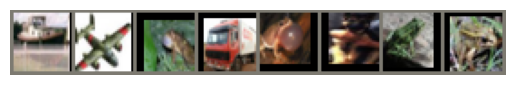

Labels:
ship airplane frog truck frog dog frog frog


In [29]:
import matplotlib.pyplot as plt
import numpy as np

def imshow(img):
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    std = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)

    img = img.cpu() * std +mean
    img = torch.clamp(img, 0, 1)

    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis("off")
    plt.show()

images, labels = next(iter(train_loader))

imshow(torchvision.utils.make_grid(images[:8]))

print("Labels:")
print(" ".join(classes[labels[j]] for j in range(8)))
#now I can see the images with lables

In [30]:

model = myAlexNet(dropout_p=0.0).to(device)

ceLoss = nn.CrossEntropyLoss() #loss function

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001 #learning rate
)

In [34]:
def train_one_epoch(model, train_loader, ceLoss, optimizer, device): #trains for one 1 batch in 1 epoch
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = ceLoss(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [35]:
def evaluate(model, data_loader, ceLoss, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = ceLoss(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc, all_labels, all_preds

In [36]:
num_epochs = 30

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        ceLoss,
        optimizer,
        device
    )

    val_loss, val_acc, _, _ = evaluate(
        model,
        val_loader,
        ceLoss,
        device
    )

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f}, "
        f"Train Acc: {train_acc:.4f}, "
        f"Val Loss: {val_loss:.4f}, "
        f"Val Acc: {val_acc:.4f}"
    )

Epoch [1/30] Train Loss: 1.7174, Train Acc: 0.3483, Val Loss: 1.4743, Val Acc: 0.4466
Epoch [2/30] Train Loss: 1.2760, Train Acc: 0.5333, Val Loss: 1.0976, Val Acc: 0.6052
Epoch [3/30] Train Loss: 1.0583, Train Acc: 0.6214, Val Loss: 1.0016, Val Acc: 0.6412
Epoch [4/30] Train Loss: 0.9123, Train Acc: 0.6776, Val Loss: 0.8682, Val Acc: 0.6842
Epoch [5/30] Train Loss: 0.8057, Train Acc: 0.7183, Val Loss: 0.8119, Val Acc: 0.7128
Epoch [6/30] Train Loss: 0.7272, Train Acc: 0.7447, Val Loss: 0.7262, Val Acc: 0.7356
Epoch [7/30] Train Loss: 0.6658, Train Acc: 0.7680, Val Loss: 0.7324, Val Acc: 0.7360
Epoch [8/30] Train Loss: 0.6179, Train Acc: 0.7848, Val Loss: 0.6537, Val Acc: 0.7740
Epoch [9/30] Train Loss: 0.5769, Train Acc: 0.7986, Val Loss: 0.6528, Val Acc: 0.7772
Epoch [10/30] Train Loss: 0.5458, Train Acc: 0.8117, Val Loss: 0.6065, Val Acc: 0.7872
Epoch [11/30] Train Loss: 0.5108, Train Acc: 0.8232, Val Loss: 0.6230, Val Acc: 0.7910
Epoch [12/30] Train Loss: 0.4890, Train Acc: 0.8306,

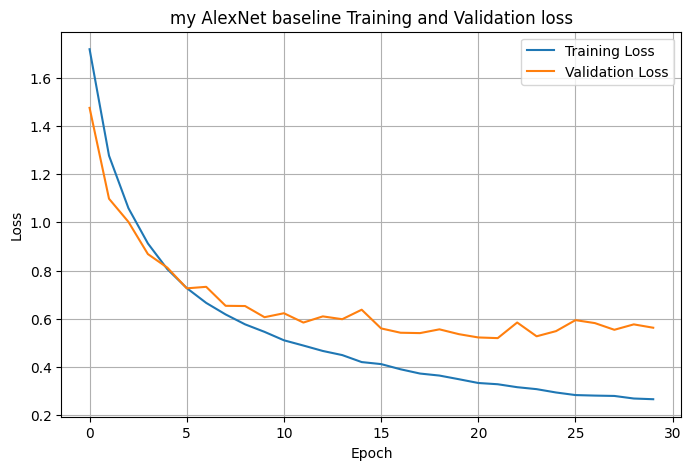

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Training Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("my AlexNet baseline Training and Validation loss")
plt.legend()
plt.grid(True)
plt.show()

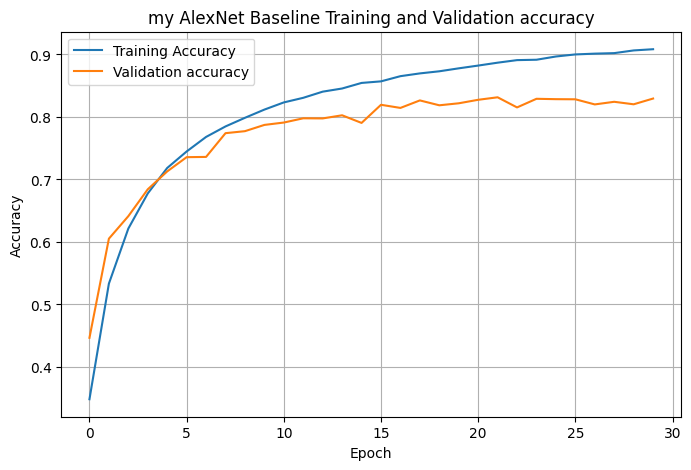

In [38]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_acc"], label="Training Accuracy")
plt.plot(history["val_acc"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("my AlexNet Baseline Training and Validation accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [42]:
import matplotlib.pyplot as plt
import torch

def visualize_first_layer_filters(model, save_path=None):
    model.eval()

    # First conv layer
    first_conv = model.features[0]

    # Shape
    filters = first_conv.weight.detach().cpu()

    # Normalize each filter separately for better display
    num_filters = min(filters.shape[0], 32)

    plt.figure(figsize=(12, 6))

    for i in range(num_filters):
        filt = filters[i]

        # Convert from [channels, height, width] to [height, width, channels]
        filt = filt.permute(1, 2, 0)

        # Normalize to 0–1
        filt_min = filt.min()
        filt_max = filt.max()
        filt = (filt - filt_min) / (filt_max - filt_min + 1e-8)

        plt.subplot(4, 8, i + 1)
        plt.imshow(filt)
        plt.axis("off")

    plt.suptitle("Layer Filters visulization")
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

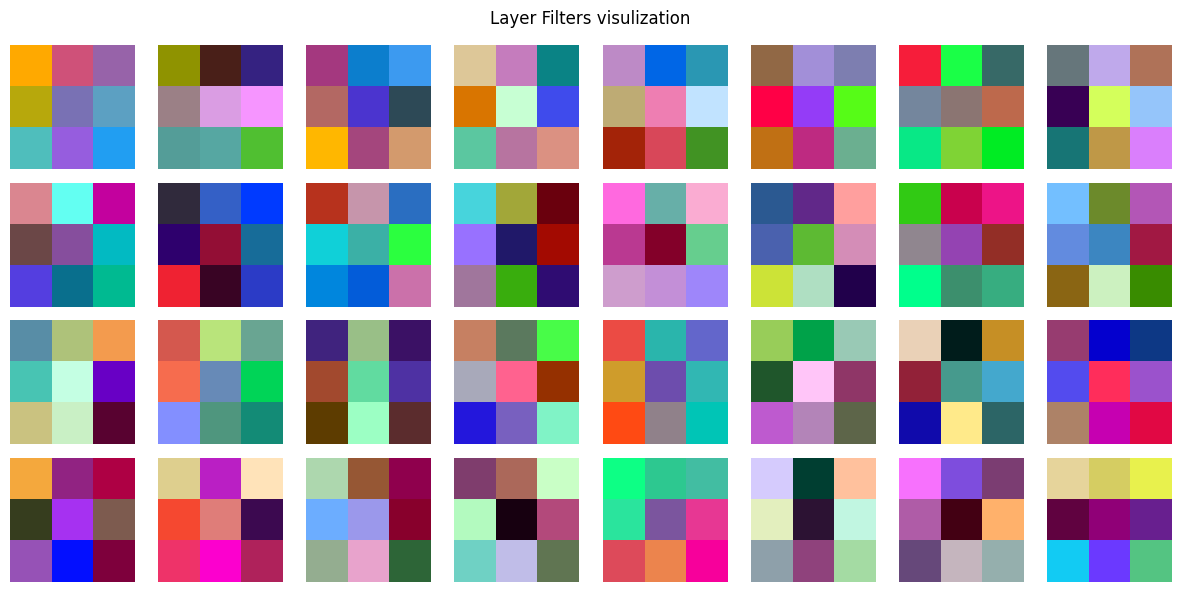

In [43]:
visualize_first_layer_filters(
    model,
    save_path="my_alexnet_first_layer_filters.png"
)

In [44]:
test_loss, test_acc, y_true, y_pred = evaluate(
    model,
    test_loader,
    ceLoss,
    device
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Test Loss: 0.5728
Test Accuracy: 0.8358


In [ ]:
torch.save(model.state_dict(), "my_alexnet_baseline.pth")

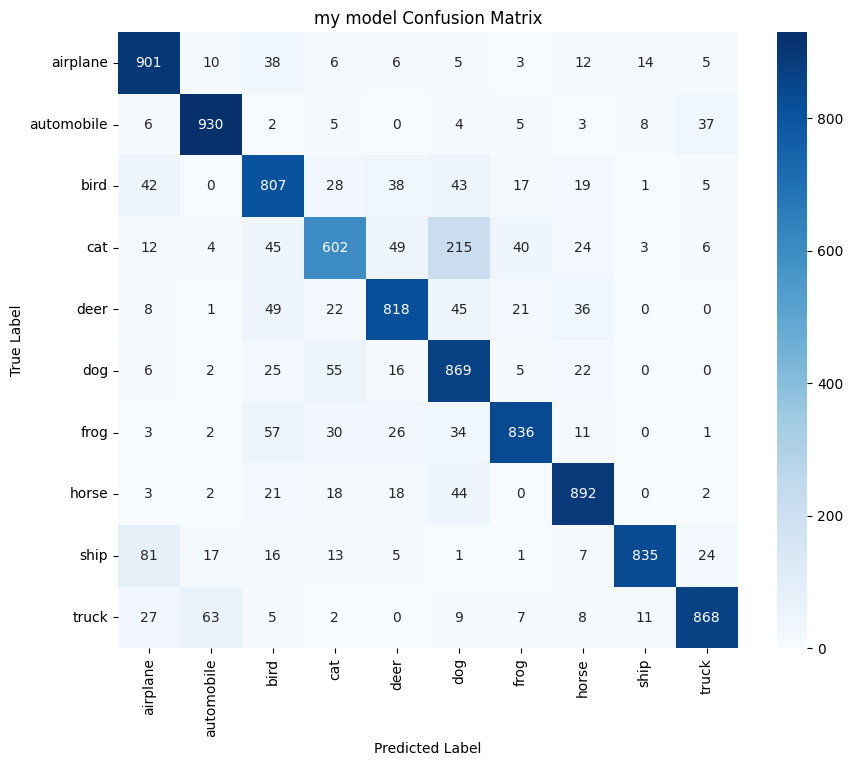

In [47]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

classes = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("my model Confusion Matrix")
plt.show()

In [ ]:
def run_experiment(dropout_p, num_epochs=30, lr=0.001, weight_decay=0.0):
    model = myAlexNet(dropout_p=dropout_p).to(device)

    ceLoss = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, ceLoss, optimizer, device
        )

        val_loss, val_acc, _, _ = evaluate(
            model, val_loader, ceLoss, device
        )

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Dropout p={dropout_p} | Epoch [{epoch+1}/{num_epochs}] "
            f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, "
            f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
        )

    return model, history

In [ ]:
dropout03_model, dropout03_history = run_experiment(
    dropout_p=0.3,
    num_epochs=30,
    lr=0.001
)

Dropout p=0.3 | Epoch [1/30] Train Loss: 1.8158, Train Acc: 0.3056, Val Loss: 1.5537, Val Acc: 0.4266
Dropout p=0.3 | Epoch [2/30] Train Loss: 1.3954, Train Acc: 0.4877, Val Loss: 1.2139, Val Acc: 0.5624
Dropout p=0.3 | Epoch [3/30] Train Loss: 1.1750, Train Acc: 0.5789, Val Loss: 1.0880, Val Acc: 0.6102
Dropout p=0.3 | Epoch [4/30] Train Loss: 1.0195, Train Acc: 0.6379, Val Loss: 0.9713, Val Acc: 0.6492
Dropout p=0.3 | Epoch [5/30] Train Loss: 0.9212, Train Acc: 0.6781, Val Loss: 0.9314, Val Acc: 0.6728
Dropout p=0.3 | Epoch [6/30] Train Loss: 0.8517, Train Acc: 0.7020, Val Loss: 0.8107, Val Acc: 0.7154
Dropout p=0.3 | Epoch [7/30] Train Loss: 0.7788, Train Acc: 0.7294, Val Loss: 0.7564, Val Acc: 0.7288
Dropout p=0.3 | Epoch [8/30] Train Loss: 0.7346, Train Acc: 0.7474, Val Loss: 0.7566, Val Acc: 0.7312
Dropout p=0.3 | Epoch [9/30] Train Loss: 0.6997, Train Acc: 0.7610, Val Loss: 0.7703, Val Acc: 0.7302
Dropout p=0.3 | Epoch [10/30] Train Loss: 0.6673, Train Acc: 0.7720, Val Loss: 0.7

In [ ]:
dropout05_model, dropout05_history = run_experiment(
    dropout_p=0.5,
    num_epochs=30,
    lr=0.001
)

Dropout p=0.5 | Epoch [1/30] Train Loss: 1.8355, Train Acc: 0.2952, Val Loss: 1.5160, Val Acc: 0.4320
Dropout p=0.5 | Epoch [2/30] Train Loss: 1.4610, Train Acc: 0.4650, Val Loss: 1.2780, Val Acc: 0.5390
Dropout p=0.5 | Epoch [3/30] Train Loss: 1.2625, Train Acc: 0.5489, Val Loss: 1.1397, Val Acc: 0.5926
Dropout p=0.5 | Epoch [4/30] Train Loss: 1.1333, Train Acc: 0.6000, Val Loss: 1.0102, Val Acc: 0.6368
Dropout p=0.5 | Epoch [5/30] Train Loss: 1.0236, Train Acc: 0.6399, Val Loss: 0.9669, Val Acc: 0.6586
Dropout p=0.5 | Epoch [6/30] Train Loss: 0.9322, Train Acc: 0.6806, Val Loss: 0.9022, Val Acc: 0.6846
Dropout p=0.5 | Epoch [7/30] Train Loss: 0.8711, Train Acc: 0.6989, Val Loss: 0.8536, Val Acc: 0.7064
Dropout p=0.5 | Epoch [8/30] Train Loss: 0.8147, Train Acc: 0.7242, Val Loss: 0.7969, Val Acc: 0.7238
Dropout p=0.5 | Epoch [9/30] Train Loss: 0.7704, Train Acc: 0.7385, Val Loss: 0.7317, Val Acc: 0.7420
Dropout p=0.5 | Epoch [10/30] Train Loss: 0.7232, Train Acc: 0.7560, Val Loss: 0.7

In [ ]:
baseline_history = history
baseline_model = model
histories = {
    "Baseline": baseline_history,
    "Dropout p=0.3": dropout03_history,
    "Dropout p=0.5": dropout05_history
}

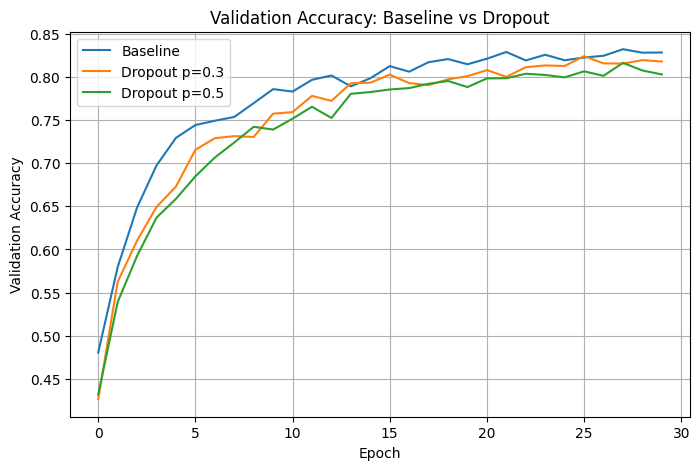

In [ ]:
plt.figure(figsize=(8, 5))

for label, hist in histories.items():
    plt.plot(hist["val_acc"], label=label)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy: Baseline vs Dropout")
plt.legend()
plt.grid(True)
plt.show()

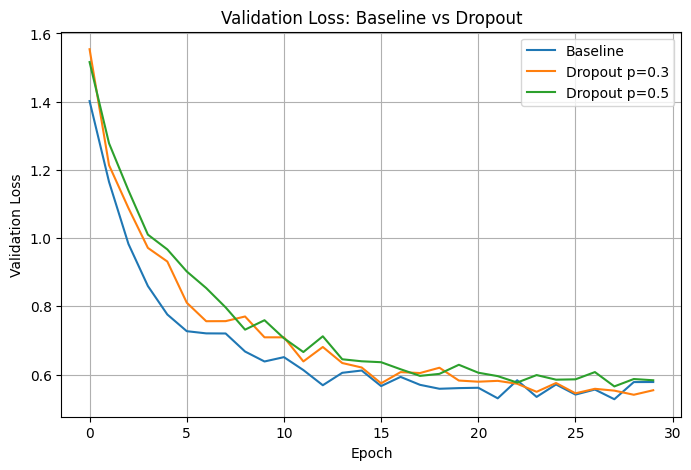

In [ ]:
plt.figure(figsize=(8, 5))

for label, hist in histories.items():
    plt.plot(hist["val_loss"], label=label)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss: Baseline vs Dropout")
plt.legend()
plt.grid(True)
plt.show()

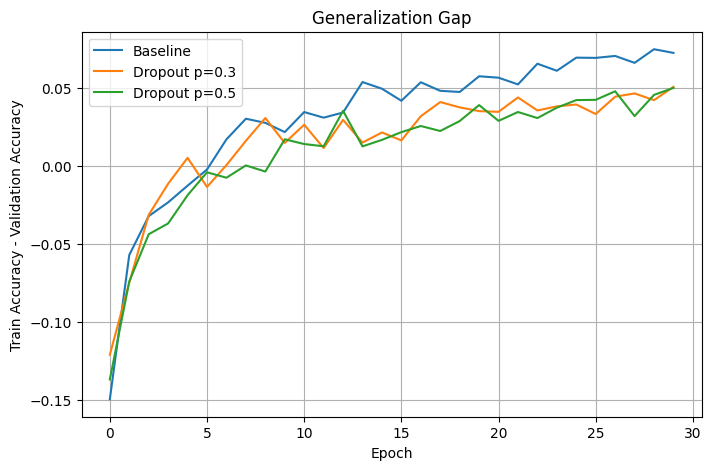

In [ ]:
plt.figure(figsize=(8, 5))

for label, hist in histories.items():
    gap = [t - v for t, v in zip(hist["train_acc"], hist["val_acc"])]
    plt.plot(gap, label=label)

plt.xlabel("Epoch")
plt.ylabel("Train Accuracy - Validation Accuracy")
plt.title("Generalization Gap")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
ceLoss = nn.CrossEntropyLoss()

models = {
    "Baseline": baseline_model,
    "Dropout p=0.3": dropout03_model,
    "Dropout p=0.5": dropout05_model
}

for name, trained_model in models.items():
    test_loss, test_acc, _, _ = evaluate(
        trained_model,
        test_loader,
        ceLoss,
        device
    )

    print(f"{name}: Test Loss = {test_loss:.4f}, Test Accuracy = {test_acc:.4f}")

Baseline: Test Loss = 0.5872, Test Accuracy = 0.8353
Dropout p=0.3: Test Loss = 0.5559, Test Accuracy = 0.8212
Dropout p=0.5: Test Loss = 0.5676, Test Accuracy = 0.8141


Bonus

In [ ]:
def run_experiment(dropout_p, weight_decay=0.0):
  optimizer = optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=weight_decay
)
  l2_model, l2_history = run_experiment(
    dropout_p=0.0,
    weight_decay=1e-4
)

In [ ]:
def run_experiment(dropout_p, num_epochs=30, lr=0.001, weight_decay=0.0):
    model = myAlexNet(dropout_p=dropout_p).to(device)

    ceLoss = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, ceLoss, optimizer, device
        )

        val_loss, val_acc, _, _ = evaluate(
            model, val_loader, ceLoss, device
        )

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Dropout p={dropout_p} | Epoch [{epoch+1}/{num_epochs}] "
            f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, "
            f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
        )

    return model, history

l2_model, l2_history = run_experiment(
    dropout_p=0.0,
    num_epochs=30,
    lr=0.001,
    weight_decay=1e-4
)

Dropout p=0.0 | Epoch [1/30] Train Loss: 1.8263, Train Acc: 0.3058, Val Loss: 1.5571, Val Acc: 0.4092
Dropout p=0.0 | Epoch [2/30] Train Loss: 1.4283, Train Acc: 0.4683, Val Loss: 1.3504, Val Acc: 0.5000
Dropout p=0.0 | Epoch [3/30] Train Loss: 1.2207, Train Acc: 0.5529, Val Loss: 1.1407, Val Acc: 0.6008
Dropout p=0.0 | Epoch [4/30] Train Loss: 1.0663, Train Acc: 0.6178, Val Loss: 1.0037, Val Acc: 0.6330
Dropout p=0.0 | Epoch [5/30] Train Loss: 0.9390, Train Acc: 0.6656, Val Loss: 0.9070, Val Acc: 0.6780
Dropout p=0.0 | Epoch [6/30] Train Loss: 0.8465, Train Acc: 0.7004, Val Loss: 0.8370, Val Acc: 0.7044
Dropout p=0.0 | Epoch [7/30] Train Loss: 0.7765, Train Acc: 0.7279, Val Loss: 0.8150, Val Acc: 0.7212
Dropout p=0.0 | Epoch [8/30] Train Loss: 0.7179, Train Acc: 0.7502, Val Loss: 0.7373, Val Acc: 0.7446
Dropout p=0.0 | Epoch [9/30] Train Loss: 0.6669, Train Acc: 0.7665, Val Loss: 0.6986, Val Acc: 0.7530
Dropout p=0.0 | Epoch [10/30] Train Loss: 0.6353, Train Acc: 0.7796, Val Loss: 0.7

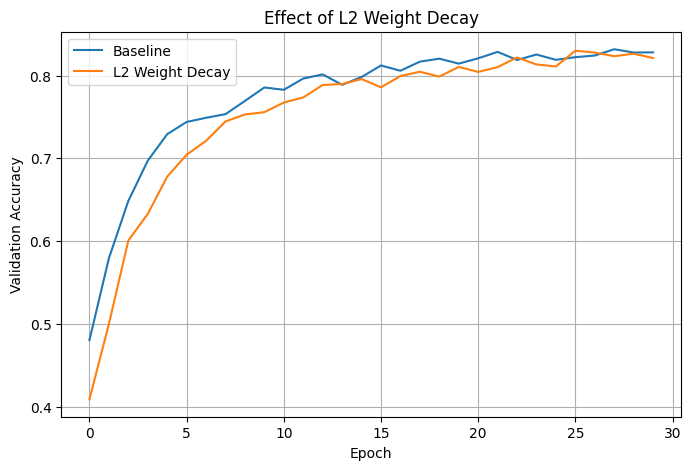

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(
    baseline_history["val_acc"],
    label="Baseline"
)

plt.plot(
    l2_history["val_acc"],
    label="L2 Weight Decay"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Effect of L2 Weight Decay")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
baseline_test_loss, baseline_test_acc, _, _ = evaluate(
    baseline_model,
    test_loader,
    ceLoss,
    device
)

l2_test_loss, l2_test_acc, _, _ = evaluate(
    l2_model,
    test_loader,
    ceLoss,
    device
)

print("Baseline:", baseline_test_acc)
print("L2:", l2_test_acc)

Baseline: 0.8353
L2: 0.825


2

In [ ]:
class myVGG(nn.Module):
    def __init__(self, config, num_classes=10, dropout_p=0.0, use_batchnorm=False):
        super().__init__()

        self.features = self._make_layers(config, use_batchnorm)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_p),

            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_p),

            nn.Linear(256, num_classes)
        )

    def _make_layers(self, config, use_batchnorm):
        layers = []
        in_channels = 3

        for layer in config:
            if layer == "M":
                layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
            else:
                conv = nn.Conv2d(
                    in_channels,
                    layer,
                    kernel_size=3,
                    padding=1
                )

                if use_batchnorm:
                    layers.extend([
                        conv,
                        nn.BatchNorm2d(layer),
                        nn.ReLU(inplace=True)
                    ])
                else:
                    layers.extend([
                        conv,
                        nn.ReLU(inplace=True)
                    ])

                in_channels = layer

        layers.append(nn.AdaptiveAvgPool2d((1, 1)))

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [ ]:
VGG_CONFIGS = {
    "VGG11": [64, "M", 128, "M", 256, 256, "M", 512, 512, "M", 512, 512, "M"],

    "VGG13": [64, 64, "M", 128, 128, "M", 256, 256, "M",
              512, 512, "M", 512, 512, "M"],

    "VGG16": [64, 64, "M", 128, 128, "M", 256, 256, 256, "M",
              512, 512, 512, "M", 512, 512, 512, "M"],

    "VGG19": [64, 64, "M", 128, 128, "M", 256, 256, 256, 256, "M",
              512, 512, 512, 512, "M", 512, 512, 512, 512, "M"]
}

In [ ]:
def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


alexnet_params = count_trainable_params(baseline_model)
print(f"my AlexNet parameters: {alexnet_params:,}")

vgg_param_counts = {}

for name, config in VGG_CONFIGS.items():
    model_temp = myVGG(
        config=config,
        num_classes=10,
        dropout_p=0.0,
        use_batchnorm=False
    ).to(device)

    params = count_trainable_params(model_temp)
    vgg_param_counts[name] = params

    print(f"{name}: {params:,} parameters")

Modified AlexNet parameters: 4,483,146
VGG11: 9,617,034 parameters
VGG13: 9,801,546 parameters
VGG16: 15,111,242 parameters
VGG19: 20,420,938 parameters


In [ ]:
closest_vgg_name = min(
    vgg_param_counts,
    key=lambda name: abs(vgg_param_counts[name] - alexnet_params)
)

closest_vgg_config = VGG_CONFIGS[closest_vgg_name]

print("Closest VGG model:", closest_vgg_name)
print("VGG parameters:", f"{vgg_param_counts[closest_vgg_name]:,}")
print("AlexNet parameters:", f"{alexnet_params:,}")

Closest VGG model: VGG11
VGG parameters: 9,617,034
AlexNet parameters: 4,483,146


In [ ]:
import time

def run_vgg_experiment(
    config,
    model_name,
    dropout_p=0.0,
    num_epochs=30,
    lr=0.001,
    weight_decay=0.0,
    use_batchnorm=False
):
    model = myVGG(
        config=config,
        num_classes=10,
        dropout_p=dropout_p,
        use_batchnorm=use_batchnorm
    ).to(device)

    ceLoss = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "epoch_time": []
    }

    for epoch in range(num_epochs):
        start_time = time.time()

        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            ceLoss,
            optimizer,
            device
        )

        val_loss, val_acc, _, _ = evaluate(
            model,
            val_loader,
            ceLoss,
            device
        )

        epoch_time = time.time() - start_time

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["epoch_time"].append(epoch_time)

        print(
            f"{model_name} | Dropout p={dropout_p} | "
            f"Epoch [{epoch+1}/{num_epochs}] "
            f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, "
            f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, "
            f"Time: {epoch_time:.2f}s"
        )

    return model, history

a

In [ ]:
vgg_baseline_model, vgg_baseline_history = run_vgg_experiment(
    config=closest_vgg_config,
    model_name=f"{closest_vgg_name} Baseline",
    dropout_p=0.0,
    num_epochs=30,
    lr=0.001,
    weight_decay=0.0,
    use_batchnorm=False
)

VGG11 Baseline | Dropout p=0.0 | Epoch [1/30] Train Loss: 1.9876, Train Acc: 0.2056, Val Loss: 1.7853, Val Acc: 0.2588, Time: 23.10s
VGG11 Baseline | Dropout p=0.0 | Epoch [2/30] Train Loss: 1.6599, Train Acc: 0.3502, Val Loss: 1.5080, Val Acc: 0.4264, Time: 21.13s
VGG11 Baseline | Dropout p=0.0 | Epoch [3/30] Train Loss: 1.4181, Train Acc: 0.4592, Val Loss: 1.3334, Val Acc: 0.5052, Time: 21.01s
VGG11 Baseline | Dropout p=0.0 | Epoch [4/30] Train Loss: 1.2380, Train Acc: 0.5500, Val Loss: 1.1747, Val Acc: 0.5716, Time: 19.91s
VGG11 Baseline | Dropout p=0.0 | Epoch [5/30] Train Loss: 1.0990, Train Acc: 0.6113, Val Loss: 1.0746, Val Acc: 0.6126, Time: 21.21s
VGG11 Baseline | Dropout p=0.0 | Epoch [6/30] Train Loss: 0.9759, Train Acc: 0.6572, Val Loss: 0.9653, Val Acc: 0.6622, Time: 19.92s
VGG11 Baseline | Dropout p=0.0 | Epoch [7/30] Train Loss: 0.9081, Train Acc: 0.6839, Val Loss: 0.9284, Val Acc: 0.6742, Time: 21.34s
VGG11 Baseline | Dropout p=0.0 | Epoch [8/30] Train Loss: 0.8507, Tra

In [ ]:
vgg_dropout03_model, vgg_dropout03_history = run_vgg_experiment(
    config=closest_vgg_config,
    model_name=f"{closest_vgg_name} Dropout 0.3",
    dropout_p=0.3,
    num_epochs=30,
    lr=0.001,
    weight_decay=0.0,
    use_batchnorm=False
)

VGG11 Dropout 0.3 | Dropout p=0.3 | Epoch [1/30] Train Loss: 1.9289, Train Acc: 0.2188, Val Loss: 1.7161, Val Acc: 0.3130, Time: 21.23s
VGG11 Dropout 0.3 | Dropout p=0.3 | Epoch [2/30] Train Loss: 1.5891, Train Acc: 0.3826, Val Loss: 1.4860, Val Acc: 0.4306, Time: 21.68s
VGG11 Dropout 0.3 | Dropout p=0.3 | Epoch [3/30] Train Loss: 1.3368, Train Acc: 0.5026, Val Loss: 1.1733, Val Acc: 0.5814, Time: 20.30s
VGG11 Dropout 0.3 | Dropout p=0.3 | Epoch [4/30] Train Loss: 1.1487, Train Acc: 0.5872, Val Loss: 1.0632, Val Acc: 0.6240, Time: 21.18s
VGG11 Dropout 0.3 | Dropout p=0.3 | Epoch [5/30] Train Loss: 1.0054, Train Acc: 0.6483, Val Loss: 0.9974, Val Acc: 0.6444, Time: 20.11s
VGG11 Dropout 0.3 | Dropout p=0.3 | Epoch [6/30] Train Loss: 0.9337, Train Acc: 0.6781, Val Loss: 0.8865, Val Acc: 0.6894, Time: 21.15s
VGG11 Dropout 0.3 | Dropout p=0.3 | Epoch [7/30] Train Loss: 0.8480, Train Acc: 0.7123, Val Loss: 0.8244, Val Acc: 0.7152, Time: 20.19s
VGG11 Dropout 0.3 | Dropout p=0.3 | Epoch [8/30]

In [ ]:
vgg_dropout05_model, vgg_dropout05_history = run_vgg_experiment(
    config=closest_vgg_config,
    model_name=f"{closest_vgg_name} Dropout 0.5",
    dropout_p=0.5,
    num_epochs=30,
    lr=0.001,
    weight_decay=0.0,
    use_batchnorm=False
)

VGG11 Dropout 0.5 | Dropout p=0.5 | Epoch [1/30] Train Loss: 2.0032, Train Acc: 0.1974, Val Loss: 1.8148, Val Acc: 0.2792, Time: 19.92s
VGG11 Dropout 0.5 | Dropout p=0.5 | Epoch [2/30] Train Loss: 1.7085, Train Acc: 0.3274, Val Loss: 1.5611, Val Acc: 0.4052, Time: 21.33s
VGG11 Dropout 0.5 | Dropout p=0.5 | Epoch [3/30] Train Loss: 1.5085, Train Acc: 0.4371, Val Loss: 1.3968, Val Acc: 0.5036, Time: 21.23s
VGG11 Dropout 0.5 | Dropout p=0.5 | Epoch [4/30] Train Loss: 1.3354, Train Acc: 0.5207, Val Loss: 1.2622, Val Acc: 0.5506, Time: 20.33s
VGG11 Dropout 0.5 | Dropout p=0.5 | Epoch [5/30] Train Loss: 1.2084, Train Acc: 0.5759, Val Loss: 1.1681, Val Acc: 0.5938, Time: 21.33s
VGG11 Dropout 0.5 | Dropout p=0.5 | Epoch [6/30] Train Loss: 1.0970, Train Acc: 0.6219, Val Loss: 1.0365, Val Acc: 0.6314, Time: 20.12s
VGG11 Dropout 0.5 | Dropout p=0.5 | Epoch [7/30] Train Loss: 1.0169, Train Acc: 0.6521, Val Loss: 0.9545, Val Acc: 0.6644, Time: 21.29s
VGG11 Dropout 0.5 | Dropout p=0.5 | Epoch [8/30]

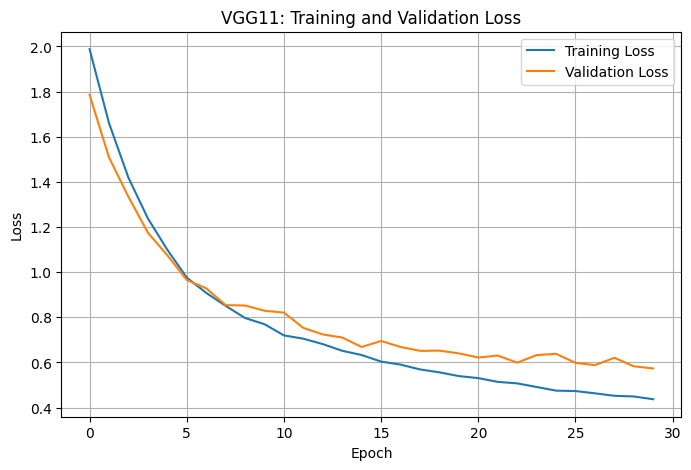

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(vgg_baseline_history["train_loss"], label="Training Loss")
plt.plot(vgg_baseline_history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"{closest_vgg_name}: Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

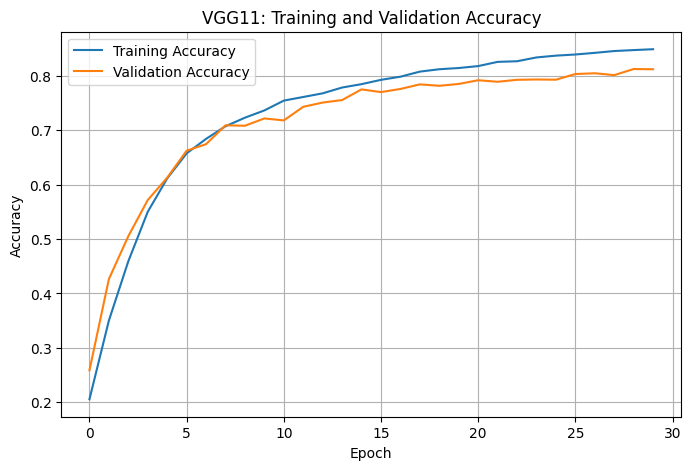

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(vgg_baseline_history["train_acc"], label="Training Accuracy")
plt.plot(vgg_baseline_history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(f"{closest_vgg_name}: Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

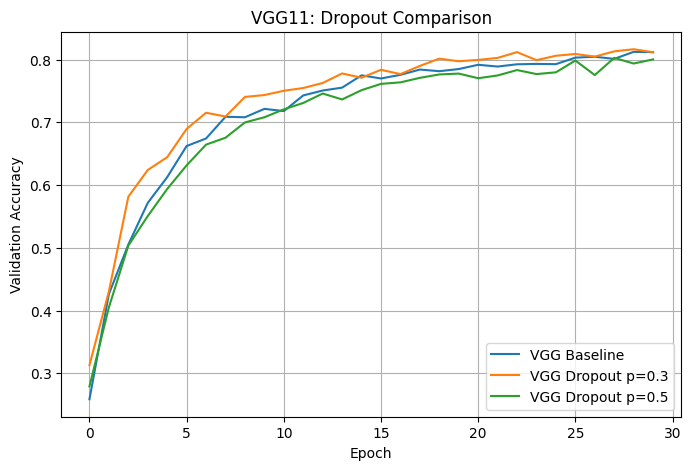

In [ ]:
vgg_histories = {
    "VGG Baseline": vgg_baseline_history,
    "VGG Dropout p=0.3": vgg_dropout03_history,
    "VGG Dropout p=0.5": vgg_dropout05_history
}

plt.figure(figsize=(8, 5))

for label, hist in vgg_histories.items():
    plt.plot(hist["val_acc"], label=label)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title(f"{closest_vgg_name}: Dropout Comparison")
plt.legend()
plt.grid(True)
plt.show()

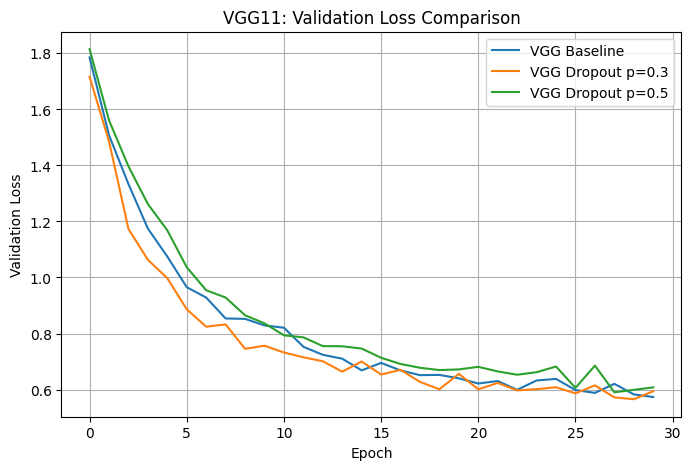

In [ ]:
plt.figure(figsize=(8, 5))

for label, hist in vgg_histories.items():
    plt.plot(hist["val_loss"], label=label)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title(f"{closest_vgg_name}: Validation Loss Comparison")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
ceLoss = nn.CrossEntropyLoss()

vgg_models = {
    "VGG Baseline": vgg_baseline_model,
    "VGG Dropout p=0.3": vgg_dropout03_model,
    "VGG Dropout p=0.5": vgg_dropout05_model
}

for name, trained_model in vgg_models.items():
    test_loss, test_acc, _, _ = evaluate(
        trained_model,
        test_loader,
        ceLoss,
        device
    )

    print(f"{name}: Test Loss = {test_loss:.4f}, Test Accuracy = {test_acc:.4f}")

VGG Baseline: Test Loss = 0.5502, Test Accuracy = 0.8239
VGG Dropout p=0.3: Test Loss = 0.5501, Test Accuracy = 0.8254
VGG Dropout p=0.5: Test Loss = 0.5828, Test Accuracy = 0.8075


In [ ]:
best_vgg_model = vgg_dropout03_model  # change if another one is better

test_loss, test_acc, y_true, y_pred = evaluate(
    best_vgg_model,
    test_loader,
    ceLoss,
    device
)

print(f"Best VGG Test Accuracy: {test_acc:.4f}")

Best VGG Test Accuracy: 0.8254


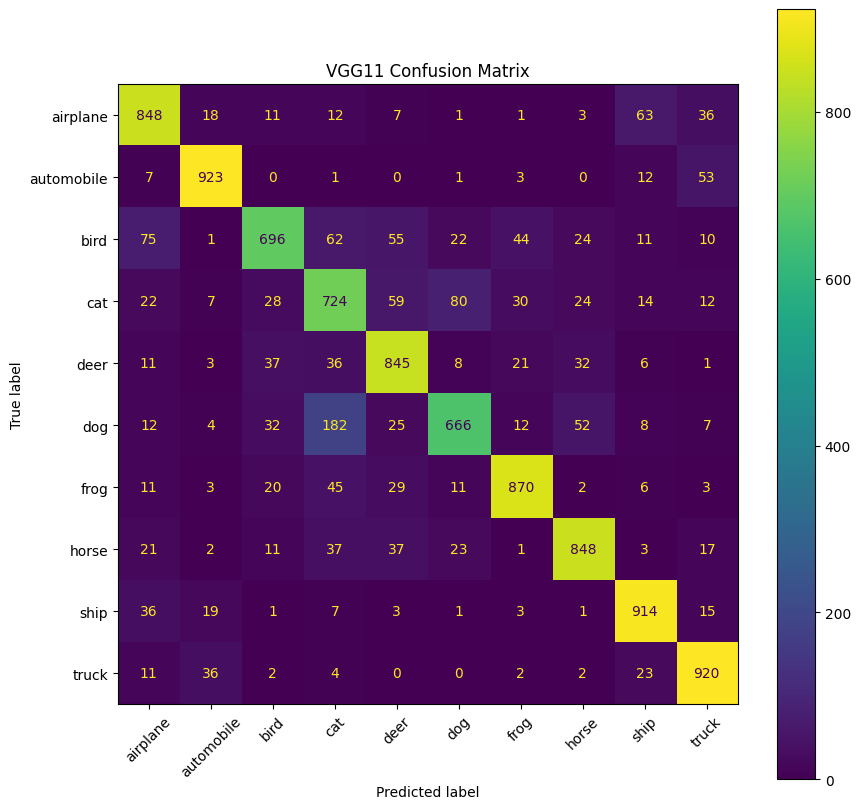

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=45)
plt.title(f"{closest_vgg_name} Confusion Matrix")
plt.show()

In [ ]:
comparison_data = {
    "Model": [
        "my AlexNet Baseline",
        f"{closest_vgg_name} Baseline",
        "my AlexNet Dropout 0.3",
        f"{closest_vgg_name} Dropout 0.3",
        "my AlexNet Dropout 0.5",
        f"{closest_vgg_name} Dropout 0.5"
    ],
    "Parameter Count": [
        count_trainable_params(baseline_model),
        count_trainable_params(vgg_baseline_model),
        count_trainable_params(dropout03_model),
        count_trainable_params(vgg_dropout03_model),
        count_trainable_params(dropout05_model),
        count_trainable_params(vgg_dropout05_model)
    ],
    "Best Validation Accuracy": [
        max(baseline_history["val_acc"]),
        max(vgg_baseline_history["val_acc"]),
        max(dropout03_history["val_acc"]),
        max(vgg_dropout03_history["val_acc"]),
        max(dropout05_history["val_acc"]),
        max(vgg_dropout05_history["val_acc"])
    ],
    "Average Epoch Time": [
        "Add from AlexNet",
        sum(vgg_baseline_history["epoch_time"]) / len(vgg_baseline_history["epoch_time"]),
        "Add from AlexNet",
        sum(vgg_dropout03_history["epoch_time"]) / len(vgg_dropout03_history["epoch_time"]),
        "Add from AlexNet",
        sum(vgg_dropout05_history["epoch_time"]) / len(vgg_dropout05_history["epoch_time"])
    ]
}

comparison_data

{'Model': ['Modified AlexNet Baseline',
  'VGG11 Baseline',
  'Modified AlexNet Dropout 0.3',
  'VGG11 Dropout 0.3',
  'Modified AlexNet Dropout 0.5',
  'VGG11 Dropout 0.5'],
 'Parameter Count': [4483146, 9617034, 4483146, 9617034, 4483146, 9617034],
 'Best Validation Accuracy': [0.8318, 0.8122, 0.8238, 0.8164, 0.816, 0.8026],
 'Average Epoch Time': ['Add from AlexNet',
  20.80289831161499,
  'Add from AlexNet',
  20.83987352848053,
  'Add from AlexNet',
  21.024483172098794]}

2bonus

In [ ]:
vgg_bn_model, vgg_bn_history = run_vgg_experiment(
    config=closest_vgg_config,
    model_name=f"{closest_vgg_name} BatchNorm",
    dropout_p=0.0,
    num_epochs=30,
    lr=0.001,
    weight_decay=0.0,
    use_batchnorm=True
)

VGG11 BatchNorm | Dropout p=0.0 | Epoch [1/30] Train Loss: 1.6407, Train Acc: 0.3539, Val Loss: 1.4753, Val Acc: 0.4566, Time: 21.64s
VGG11 BatchNorm | Dropout p=0.0 | Epoch [2/30] Train Loss: 1.1993, Train Acc: 0.5610, Val Loss: 1.0845, Val Acc: 0.6064, Time: 20.12s
VGG11 BatchNorm | Dropout p=0.0 | Epoch [3/30] Train Loss: 0.9596, Train Acc: 0.6590, Val Loss: 0.9235, Val Acc: 0.6690, Time: 21.06s
VGG11 BatchNorm | Dropout p=0.0 | Epoch [4/30] Train Loss: 0.8211, Train Acc: 0.7136, Val Loss: 0.9937, Val Acc: 0.6622, Time: 20.93s
VGG11 BatchNorm | Dropout p=0.0 | Epoch [5/30] Train Loss: 0.7233, Train Acc: 0.7495, Val Loss: 0.7449, Val Acc: 0.7364, Time: 20.39s
VGG11 BatchNorm | Dropout p=0.0 | Epoch [6/30] Train Loss: 0.6630, Train Acc: 0.7725, Val Loss: 0.6544, Val Acc: 0.7664, Time: 20.97s
VGG11 BatchNorm | Dropout p=0.0 | Epoch [7/30] Train Loss: 0.6016, Train Acc: 0.7950, Val Loss: 0.6627, Val Acc: 0.7744, Time: 20.36s
VGG11 BatchNorm | Dropout p=0.0 | Epoch [8/30] Train Loss: 0.5

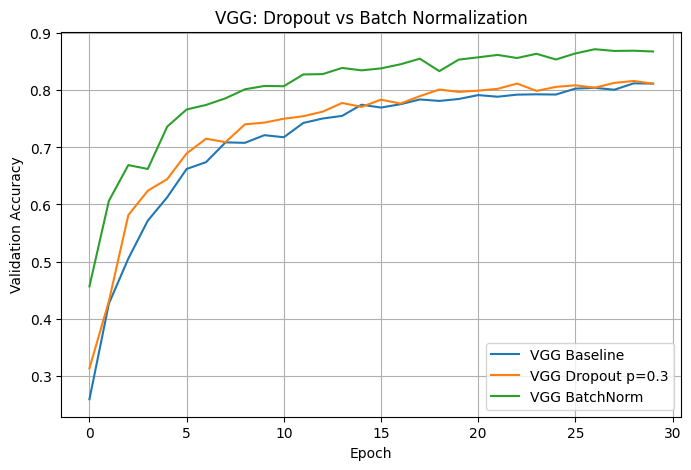

In [ ]:
bn_histories = {
    "VGG Baseline": vgg_baseline_history,
    "VGG Dropout p=0.3": vgg_dropout03_history,
    "VGG BatchNorm": vgg_bn_history
}

plt.figure(figsize=(8, 5))

for label, hist in bn_histories.items():
    plt.plot(hist["val_acc"], label=label)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("VGG: Dropout vs Batch Normalization")
plt.legend()
plt.grid(True)
plt.show()

3

## Problem 3 ResNet


In [ ]:
class BasicBlock(nn.Module):
    #Basic block used by the class ResNet-11 and ResNet-18
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels, out_channels,
            kernel_size=3, stride=stride, padding=1, bias=False
        )
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(
            out_channels, out_channels,
            kernel_size=3, stride=1, padding=1, bias=False
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        # Projection shortcut when size or channel count change
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != self.expansion * out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels, self.expansion * out_channels,
                    kernel_size=1, stride=stride, bias=False
                ),
                nn.BatchNorm2d(self.expansion * out_channels)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + self.shortcut(x)   # skip connection
        out = F.relu(out)
        return out

In [ ]:
class ResNetCIFAR(nn.Module):
#    3x3 initial convolution, no initial 7x7 convolution, no initial max pooling


    def __init__(self, block, num_blocks, num_classes=10, dropout_p=0.0):
        super().__init__()
        self.in_channels = 64

        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)

        self.layer1 = self._make_layer(block, 64,  num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(p=dropout_p)
        self.linear = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for s in strides:
            layers.append(block(self.in_channels, out_channels, s))
            self.in_channels = out_channels * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        out = self.dropout(out)
        out = self.linear(out)
        return out

In [ ]:
def ResNet11_CIFAR10(dropout_p=0.0):
    # Class baseline
    return ResNetCIFAR(
        block=BasicBlock,
        num_blocks=[1, 1, 1, 1],
        num_classes=10,
        dropout_p=dropout_p
    )


def ResNet18_CIFAR10(dropout_p=0.0):
    # ResNet-18 layout for four stages, two BasicBlocks each.
    return ResNetCIFAR(
        block=BasicBlock,
        num_blocks=[2, 2, 2, 2],
        num_classes=10,
        dropout_p=dropout_p
    )

In [ ]:
def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


print(f"ResNet-11 parameters: {count_trainable_params(resnet11):,}")
print(f"ResNet-18 parameters: {count_trainable_params(resnet18):,}")

ResNet-11 parameters: 4,903,242
ResNet-18 parameters: 11,173,962


In [ ]:
import time


def run_resnet_experiment(
    model_fn,
    model_name,
    dropout_p=0.0,
    num_epochs=50,
    lr=0.1,
    weight_decay=5e-4,
    scheduler_type="multistep"
):
    """Train a ResNet model and record loss, accuracy, LR, and epoch time."""
    model = model_fn(dropout_p=dropout_p).to(device)

    ceLoss = nn.CrossEntropyLoss()

    optimizer = optim.SGD(
        model.parameters(),
        lr=lr,
        momentum=0.9,
        weight_decay=weight_decay
    )

    if scheduler_type == "cosine":
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    else:
        # 50 epochs, at 30 and 45
        scheduler = optim.lr_scheduler.MultiStepLR(
            optimizer,
            milestones=[30, 45],
            gamma=0.1
        )

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "epoch_time": [],
        "lr": []
    }

    for epoch in range(num_epochs):
        start_time = time.time()
        current_lr = optimizer.param_groups[0]["lr"]

        train_loss, train_acc = train_one_epoch(
            model, train_loader, ceLoss, optimizer, device
        )

        val_loss, val_acc, _, _ = evaluate(
            model, val_loader, ceLoss, device
        )

        scheduler.step()
        epoch_time = time.time() - start_time

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["epoch_time"].append(epoch_time)
        history["lr"].append(current_lr)

        print(
            f"{model_name} | Dropout p={dropout_p} | "
            f"Epoch [{epoch+1}/{num_epochs}] "
            f"LR: {current_lr:.5f} | "
            f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f} | "
            f"Time: {epoch_time:.2f}s"
        )

    return model, history

In [ ]:
resnet11_baseline_model, resnet11_baseline_history = run_resnet_experiment(
    model_fn=ResNet11_CIFAR10,
    model_name="ResNet-11 Baseline",
    dropout_p=0.0,
    num_epochs=50,
    lr=0.1,
    weight_decay=5e-4
)

ResNet-11 Baseline | Dropout p=0.0 | Epoch [1/50] LR: 0.10000 | Train Loss: 1.6370, Train Acc: 0.3959 | Val Loss: 1.3704, Val Acc: 0.5006 | Time: 28.48s
ResNet-11 Baseline | Dropout p=0.0 | Epoch [2/50] LR: 0.10000 | Train Loss: 1.1502, Train Acc: 0.5834 | Val Loss: 1.1923, Val Acc: 0.5726 | Time: 24.75s
ResNet-11 Baseline | Dropout p=0.0 | Epoch [3/50] LR: 0.10000 | Train Loss: 0.9338, Train Acc: 0.6672 | Val Loss: 1.2472, Val Acc: 0.5792 | Time: 24.77s
ResNet-11 Baseline | Dropout p=0.0 | Epoch [4/50] LR: 0.10000 | Train Loss: 0.7964, Train Acc: 0.7193 | Val Loss: 1.0240, Val Acc: 0.6638 | Time: 24.89s
ResNet-11 Baseline | Dropout p=0.0 | Epoch [5/50] LR: 0.10000 | Train Loss: 0.6844, Train Acc: 0.7617 | Val Loss: 0.7549, Val Acc: 0.7282 | Time: 24.94s
ResNet-11 Baseline | Dropout p=0.0 | Epoch [6/50] LR: 0.10000 | Train Loss: 0.6216, Train Acc: 0.7847 | Val Loss: 0.6669, Val Acc: 0.7706 | Time: 24.99s
ResNet-11 Baseline | Dropout p=0.0 | Epoch [7/50] LR: 0.10000 | Train Loss: 0.5711

In [ ]:
resnet18_baseline_model, resnet18_baseline_history = run_resnet_experiment(
    model_fn=ResNet18_CIFAR10,
    model_name="ResNet-18 Baseline",
    dropout_p=0.0,
    num_epochs=50,
    lr=0.1,
    weight_decay=5e-4
)

ResNet-18 Baseline | Dropout p=0.0 | Epoch [1/50] LR: 0.10000 | Train Loss: 2.0870, Train Acc: 0.2718 | Val Loss: 1.7694, Val Acc: 0.3548 | Time: 38.75s
ResNet-18 Baseline | Dropout p=0.0 | Epoch [2/50] LR: 0.10000 | Train Loss: 1.5587, Train Acc: 0.4256 | Val Loss: 1.5240, Val Acc: 0.4304 | Time: 38.96s
ResNet-18 Baseline | Dropout p=0.0 | Epoch [3/50] LR: 0.10000 | Train Loss: 1.3735, Train Acc: 0.4963 | Val Loss: 1.3271, Val Acc: 0.5218 | Time: 38.99s
ResNet-18 Baseline | Dropout p=0.0 | Epoch [4/50] LR: 0.10000 | Train Loss: 1.1853, Train Acc: 0.5740 | Val Loss: 1.0999, Val Acc: 0.6176 | Time: 39.13s
ResNet-18 Baseline | Dropout p=0.0 | Epoch [5/50] LR: 0.10000 | Train Loss: 1.0181, Train Acc: 0.6376 | Val Loss: 1.0190, Val Acc: 0.6378 | Time: 39.11s
ResNet-18 Baseline | Dropout p=0.0 | Epoch [6/50] LR: 0.10000 | Train Loss: 0.8825, Train Acc: 0.6887 | Val Loss: 1.1069, Val Acc: 0.6246 | Time: 39.26s
ResNet-18 Baseline | Dropout p=0.0 | Epoch [7/50] LR: 0.10000 | Train Loss: 0.7736

In [ ]:
resnet11_dropout03_model, resnet11_dropout03_history = run_resnet_experiment(
    model_fn=ResNet11_CIFAR10,
    model_name="ResNet-11 Dropout 0.3",
    dropout_p=0.3,
    num_epochs=50,
    lr=0.1,
    weight_decay=5e-4
)

ResNet-11 Dropout 0.3 | Dropout p=0.3 | Epoch [1/50] LR: 0.10000 | Train Loss: 1.6535, Train Acc: 0.3962 | Val Loss: 1.3219, Val Acc: 0.5236 | Time: 25.30s
ResNet-11 Dropout 0.3 | Dropout p=0.3 | Epoch [2/50] LR: 0.10000 | Train Loss: 1.1907, Train Acc: 0.5688 | Val Loss: 1.1611, Val Acc: 0.5908 | Time: 25.32s
ResNet-11 Dropout 0.3 | Dropout p=0.3 | Epoch [3/50] LR: 0.10000 | Train Loss: 0.9717, Train Acc: 0.6514 | Val Loss: 1.0211, Val Acc: 0.6354 | Time: 25.01s
ResNet-11 Dropout 0.3 | Dropout p=0.3 | Epoch [4/50] LR: 0.10000 | Train Loss: 0.8244, Train Acc: 0.7110 | Val Loss: 1.0326, Val Acc: 0.6700 | Time: 25.07s
ResNet-11 Dropout 0.3 | Dropout p=0.3 | Epoch [5/50] LR: 0.10000 | Train Loss: 0.7187, Train Acc: 0.7489 | Val Loss: 0.7507, Val Acc: 0.7322 | Time: 25.21s
ResNet-11 Dropout 0.3 | Dropout p=0.3 | Epoch [6/50] LR: 0.10000 | Train Loss: 0.6437, Train Acc: 0.7782 | Val Loss: 0.9505, Val Acc: 0.6940 | Time: 25.04s
ResNet-11 Dropout 0.3 | Dropout p=0.3 | Epoch [7/50] LR: 0.10000

In [ ]:
resnet11_dropout05_model, resnet11_dropout05_history = run_resnet_experiment(
    model_fn=ResNet11_CIFAR10,
    model_name="ResNet-11 Dropout 0.5",
    dropout_p=0.5,
    num_epochs=50,
    lr=0.1,
    weight_decay=5e-4
)

ResNet-11 Dropout 0.5 | Dropout p=0.5 | Epoch [1/50] LR: 0.10000 | Train Loss: 1.7655, Train Acc: 0.3658 | Val Loss: 1.5117, Val Acc: 0.4698 | Time: 25.22s
ResNet-11 Dropout 0.5 | Dropout p=0.5 | Epoch [2/50] LR: 0.10000 | Train Loss: 1.2423, Train Acc: 0.5454 | Val Loss: 1.1906, Val Acc: 0.5800 | Time: 25.09s
ResNet-11 Dropout 0.5 | Dropout p=0.5 | Epoch [3/50] LR: 0.10000 | Train Loss: 1.0072, Train Acc: 0.6400 | Val Loss: 1.0552, Val Acc: 0.6184 | Time: 25.02s
ResNet-11 Dropout 0.5 | Dropout p=0.5 | Epoch [4/50] LR: 0.10000 | Train Loss: 0.8526, Train Acc: 0.7007 | Val Loss: 0.9227, Val Acc: 0.6692 | Time: 25.08s
ResNet-11 Dropout 0.5 | Dropout p=0.5 | Epoch [5/50] LR: 0.10000 | Train Loss: 0.7353, Train Acc: 0.7450 | Val Loss: 0.7923, Val Acc: 0.7232 | Time: 25.10s
ResNet-11 Dropout 0.5 | Dropout p=0.5 | Epoch [6/50] LR: 0.10000 | Train Loss: 0.6615, Train Acc: 0.7731 | Val Loss: 0.7217, Val Acc: 0.7536 | Time: 25.16s
ResNet-11 Dropout 0.5 | Dropout p=0.5 | Epoch [7/50] LR: 0.10000

In [ ]:
resnet18_dropout03_model, resnet18_dropout03_history = run_resnet_experiment(
    model_fn=ResNet18_CIFAR10,
    model_name="ResNet-18 Dropout 0.3",
    dropout_p=0.3,
    num_epochs=50,
    lr=0.1,
    weight_decay=5e-4
)

ResNet-18 Dropout 0.3 | Dropout p=0.3 | Epoch [1/50] LR: 0.10000 | Train Loss: 2.0876, Train Acc: 0.2758 | Val Loss: 1.6358, Val Acc: 0.3936 | Time: 38.71s
ResNet-18 Dropout 0.3 | Dropout p=0.3 | Epoch [2/50] LR: 0.10000 | Train Loss: 1.5094, Train Acc: 0.4422 | Val Loss: 1.3947, Val Acc: 0.4794 | Time: 38.87s
ResNet-18 Dropout 0.3 | Dropout p=0.3 | Epoch [3/50] LR: 0.10000 | Train Loss: 1.2520, Train Acc: 0.5479 | Val Loss: 1.1624, Val Acc: 0.5808 | Time: 38.98s
ResNet-18 Dropout 0.3 | Dropout p=0.3 | Epoch [4/50] LR: 0.10000 | Train Loss: 1.0380, Train Acc: 0.6305 | Val Loss: 1.0625, Val Acc: 0.6224 | Time: 39.08s
ResNet-18 Dropout 0.3 | Dropout p=0.3 | Epoch [5/50] LR: 0.10000 | Train Loss: 0.8824, Train Acc: 0.6879 | Val Loss: 0.8837, Val Acc: 0.6872 | Time: 39.09s
ResNet-18 Dropout 0.3 | Dropout p=0.3 | Epoch [6/50] LR: 0.10000 | Train Loss: 0.7577, Train Acc: 0.7364 | Val Loss: 0.7769, Val Acc: 0.7306 | Time: 39.16s
ResNet-18 Dropout 0.3 | Dropout p=0.3 | Epoch [7/50] LR: 0.10000

In [ ]:
resnet18_dropout05_model, resnet18_dropout05_history = run_resnet_experiment(
    model_fn=ResNet18_CIFAR10,
    model_name="ResNet-18 Dropout 0.5",
    dropout_p=0.5,
    num_epochs=50,
    lr=0.1,
    weight_decay=5e-4
)

ResNet-18 Dropout 0.5 | Dropout p=0.5 | Epoch [1/50] LR: 0.10000 | Train Loss: 2.1032, Train Acc: 0.2712 | Val Loss: 1.6759, Val Acc: 0.3676 | Time: 39.37s
ResNet-18 Dropout 0.5 | Dropout p=0.5 | Epoch [2/50] LR: 0.10000 | Train Loss: 1.5900, Train Acc: 0.4117 | Val Loss: 1.4918, Val Acc: 0.4590 | Time: 39.19s
ResNet-18 Dropout 0.5 | Dropout p=0.5 | Epoch [3/50] LR: 0.10000 | Train Loss: 1.3571, Train Acc: 0.5110 | Val Loss: 1.3626, Val Acc: 0.5074 | Time: 39.23s
ResNet-18 Dropout 0.5 | Dropout p=0.5 | Epoch [4/50] LR: 0.10000 | Train Loss: 1.1415, Train Acc: 0.5941 | Val Loss: 1.0354, Val Acc: 0.6282 | Time: 39.32s
ResNet-18 Dropout 0.5 | Dropout p=0.5 | Epoch [5/50] LR: 0.10000 | Train Loss: 0.9731, Train Acc: 0.6588 | Val Loss: 0.9778, Val Acc: 0.6516 | Time: 39.31s
ResNet-18 Dropout 0.5 | Dropout p=0.5 | Epoch [6/50] LR: 0.10000 | Train Loss: 0.8671, Train Acc: 0.6960 | Val Loss: 0.8745, Val Acc: 0.6914 | Time: 39.30s
ResNet-18 Dropout 0.5 | Dropout p=0.5 | Epoch [7/50] LR: 0.10000

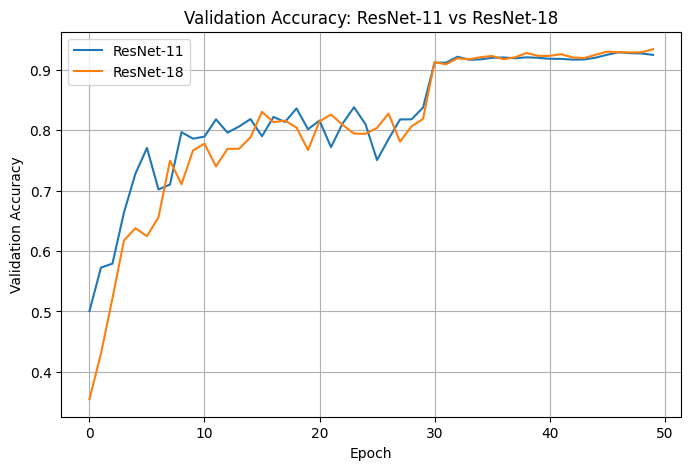

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(resnet11_baseline_history["val_acc"], label="ResNet-11")
plt.plot(resnet18_baseline_history["val_acc"], label="ResNet-18")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy: ResNet-11 vs ResNet-18")
plt.legend()
plt.grid(True)
plt.show()

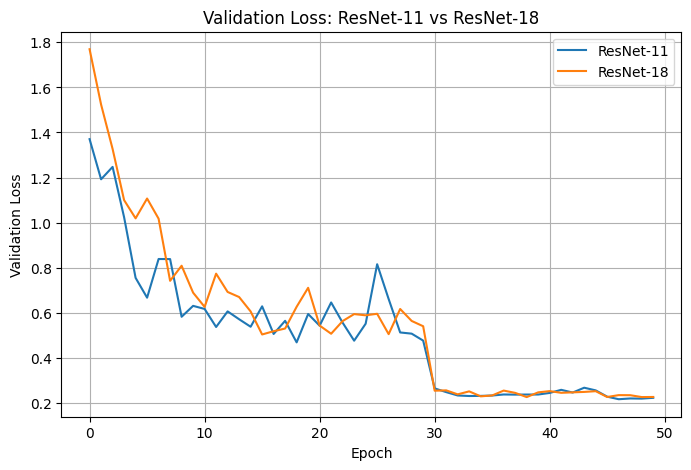

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(resnet11_baseline_history["val_loss"], label="ResNet-11")
plt.plot(resnet18_baseline_history["val_loss"], label="ResNet-18")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss: ResNet-11 vs ResNet-18")
plt.legend()
plt.grid(True)
plt.show()

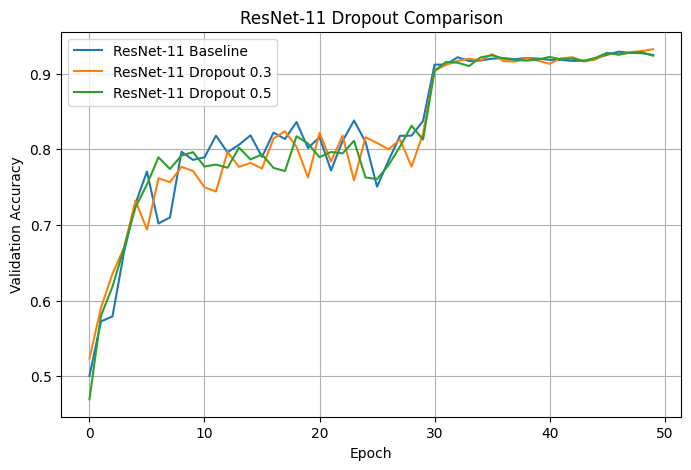

In [ ]:
resnet11_histories = {
    "ResNet-11 Baseline": resnet11_baseline_history,
    "ResNet-11 Dropout 0.3": resnet11_dropout03_history,
    "ResNet-11 Dropout 0.5": resnet11_dropout05_history
}

plt.figure(figsize=(8, 5))

for label, hist in resnet11_histories.items():
    plt.plot(hist["val_acc"], label=label)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("ResNet-11 Dropout Comparison")
plt.legend()
plt.grid(True)
plt.show()

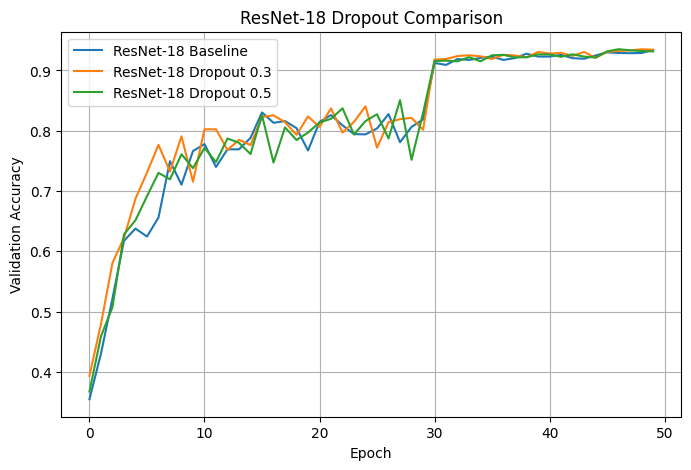

In [ ]:
resnet18_histories = {
    "ResNet-18 Baseline": resnet18_baseline_history,
    "ResNet-18 Dropout 0.3": resnet18_dropout03_history,
    "ResNet-18 Dropout 0.5": resnet18_dropout05_history
}

plt.figure(figsize=(8, 5))

for label, hist in resnet18_histories.items():
    plt.plot(hist["val_acc"], label=label)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("ResNet-18 Dropout Comparison")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
ceLoss = nn.CrossEntropyLoss()

resnet_models = {
    "ResNet-11 Baseline": resnet11_baseline_model,
    "ResNet-11 Dropout 0.3": resnet11_dropout03_model,
    "ResNet-11 Dropout 0.5": resnet11_dropout05_model,
    "ResNet-18 Baseline": resnet18_baseline_model,
    "ResNet-18 Dropout 0.3": resnet18_dropout03_model,
    "ResNet-18 Dropout 0.5": resnet18_dropout05_model
}

resnet_test_results = {}

for name, trained_model in resnet_models.items():
    test_loss, test_acc, _, _ = evaluate(
        trained_model,
        test_loader,
        ceLoss,
        device
    )

    resnet_test_results[name] = {
        "test_loss": test_loss,
        "test_acc": test_acc,
        "params": count_trainable_params(trained_model)
    }

    print(f"{name}: Test Loss = {test_loss:.4f}, Test Accuracy = {test_acc:.4f}")

ResNet-11 Baseline: Test Loss = 0.2368, Test Accuracy = 0.9281
ResNet-11 Dropout 0.3: Test Loss = 0.2497, Test Accuracy = 0.9265
ResNet-11 Dropout 0.5: Test Loss = 0.2432, Test Accuracy = 0.9265
ResNet-18 Baseline: Test Loss = 0.2412, Test Accuracy = 0.9313
ResNet-18 Dropout 0.3: Test Loss = 0.2392, Test Accuracy = 0.9314
ResNet-18 Dropout 0.5: Test Loss = 0.2483, Test Accuracy = 0.9337


In [ ]:
# Automatically pick the best ResNet-18 variant from the test results.
best_resnet18_name = max(
    [name for name in resnet_test_results if name.startswith("ResNet-18")],
    key=lambda name: resnet_test_results[name]["test_acc"]
)

best_resnet18_model = resnet_models[best_resnet18_name]
best_resnet18_test_acc = resnet_test_results[best_resnet18_name]["test_acc"]
best_resnet18_avg_epoch_time = sum(
    globals()[best_resnet18_name.lower().replace("-", "").replace(" ", "_").replace(".", "") + "_history"].get("epoch_time", [])
) / len(globals()[best_resnet18_name.lower().replace("-", "").replace(" ", "_").replace(".", "") + "_history"].get("epoch_time", [1])) if False else None

# Simpler explicit mapping for histories
resnet_history_map = {
    "ResNet-11 Baseline": resnet11_baseline_history,
    "ResNet-11 Dropout 0.3": resnet11_dropout03_history,
    "ResNet-11 Dropout 0.5": resnet11_dropout05_history,
    "ResNet-18 Baseline": resnet18_baseline_history,
    "ResNet-18 Dropout 0.3": resnet18_dropout03_history,
    "ResNet-18 Dropout 0.5": resnet18_dropout05_history,
}
best_resnet18_avg_epoch_time = sum(resnet_history_map[best_resnet18_name]["epoch_time"]) / len(resnet_history_map[best_resnet18_name]["epoch_time"])

# Also pick best ResNet-11 for the final comparison table.
best_resnet11_name = max(
    [name for name in resnet_test_results if name.startswith("ResNet-11")],
    key=lambda name: resnet_test_results[name]["test_acc"]
)
best_resnet11_model = resnet_models[best_resnet11_name]
best_resnet11_test_acc = resnet_test_results[best_resnet11_name]["test_acc"]
best_resnet11_avg_epoch_time = sum(resnet_history_map[best_resnet11_name]["epoch_time"]) / len(resnet_history_map[best_resnet11_name]["epoch_time"])

print("Best ResNet-11:", best_resnet11_name, f"Test Acc = {best_resnet11_test_acc:.4f}")
print("Best ResNet-18:", best_resnet18_name, f"Test Acc = {best_resnet18_test_acc:.4f}")

# Evaluate again to get labels/predictions for the confusion matrix.
test_loss, test_acc, y_true, y_pred = evaluate(
    best_resnet18_model,
    test_loader,
    ceLoss,
    device
)

print(f"Best ResNet-18 Test Accuracy: {test_acc:.4f}")

Best ResNet-11: ResNet-11 Baseline Test Acc = 0.9281
Best ResNet-18: ResNet-18 Dropout 0.5 Test Acc = 0.9337
Best ResNet-18 Test Accuracy: 0.9337


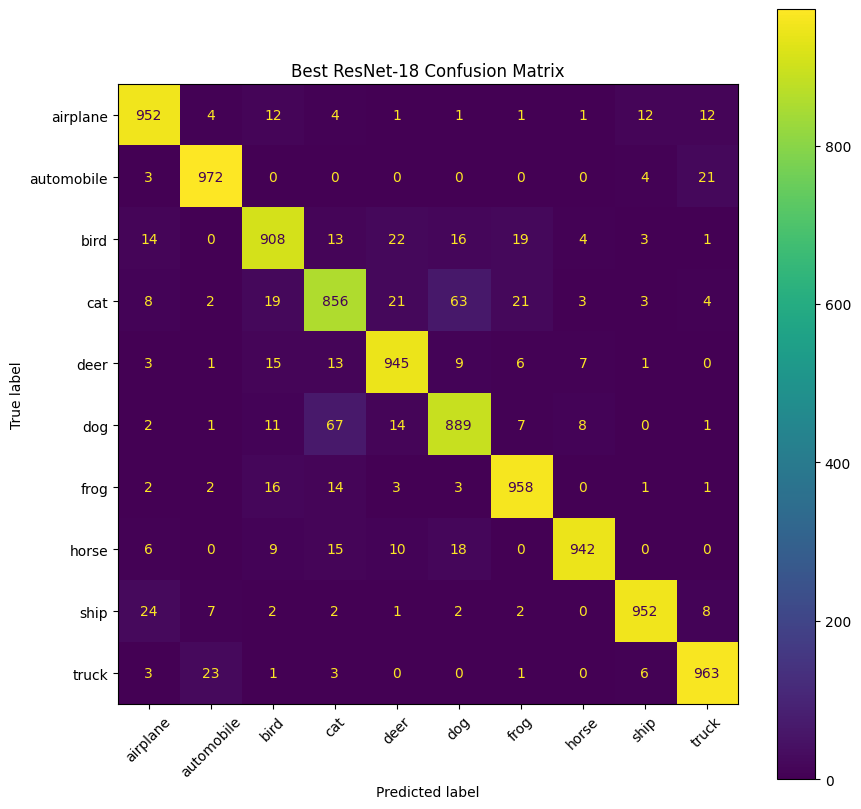

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("Best ResNet-18 Confusion Matrix")
plt.show()

In [ ]:
import pandas as pd

# Choose best AlexNet and VGG manually based on your earlier test results.
# Change these if your best models were different.
# This avoids NameError crashes in the final comparison table.
if "best_alexnet_model" not in globals():
    if "dropout03_model" in globals():
        best_alexnet_model = dropout03_model
        best_alexnet_history = dropout03_history
    else:
        best_alexnet_model = baseline_model
        best_alexnet_history = baseline_history
# Ensure best_alexnet_history is defined if best_alexnet_model was set in a prior cell.
if "best_alexnet_history" not in globals():
    if "dropout03_model" in globals() and best_alexnet_model is dropout03_model:
        best_alexnet_history = dropout03_history
    else:
        best_alexnet_history = baseline_history

if "best_vgg_model" not in globals():
    if "vgg_dropout03_model" in globals():
        best_vgg_model = vgg_dropout03_model
        best_vgg_history = vgg_dropout03_history
    else:
        best_vgg_model = vgg_baseline_model
        best_vgg_history = vgg_baseline_history
# Ensure best_vgg_history is defined if best_vgg_model was set in a prior cell.
if "best_vgg_history" not in globals():
    if "vgg_dropout03_model" in globals() and best_vgg_model is vgg_dropout03_model:
        best_vgg_history = vgg_dropout03_history
    else:
        best_vgg_history = vgg_baseline_history

ceLoss = nn.CrossEntropyLoss()

# Compute test accuracies if they were not already saved.
if "best_alexnet_test_acc" not in globals():
    _, best_alexnet_test_acc, _, _ = evaluate(best_alexnet_model, test_loader, ceLoss, device)

if "best_vgg_test_acc" not in globals():
    _, best_vgg_test_acc, _, _ = evaluate(best_vgg_model, test_loader, ceLoss, device)

# Compute average epoch times safely. If an older history has no timing, display None.
def safe_avg_epoch_time(history):
    if isinstance(history, dict) and "epoch_time" in history and len(history["epoch_time"]) > 0:
        return sum(history["epoch_time"]) / len(history["epoch_time"])
    return None

best_alexnet_avg_epoch_time = safe_avg_epoch_time(best_alexnet_history)
best_vgg_avg_epoch_time = safe_avg_epoch_time(best_vgg_history)

final_results = {
    "Architecture": [
        "Best AlexNet",
        "Best VGGNet",
        "Best ResNet-11",
        "Best ResNet-18"
    ],
    "Selected Variant": [
        "Set manually/check above",
        "Set manually/check above",
        best_resnet11_name,
        best_resnet18_name
    ],
    "Parameter Count": [
        count_trainable_params(best_alexnet_model),
        count_trainable_params(best_vgg_model),
        count_trainable_params(best_resnet11_model),
        count_trainable_params(best_resnet18_model)
    ],
    "Test Accuracy": [
        best_alexnet_test_acc,
        best_vgg_test_acc,
        best_resnet11_test_acc,
        best_resnet18_test_acc
    ],
    "Avg Epoch Time (s)": [
        best_alexnet_avg_epoch_time,
        best_vgg_avg_epoch_time,
        best_resnet11_avg_epoch_time,
        best_resnet18_avg_epoch_time
    ]
}

final_results_df = pd.DataFrame(final_results)
final_results_df

,Architecture,Selected Variant,Parameter Count,Test Accuracy,Avg Epoch Time (s)
0,Best AlexNet,Set manually/check above,4483146,0.8212,NaN
1,Best VGGNet,Set manually/check above,9617034,0.8254,20.839874
2,Best ResNet-11,ResNet-11 Baseline,4903242,0.9281,25.073561
3,Best ResNet-18,ResNet-18 Dropout 0.5,11173962,0.9337,39.222936


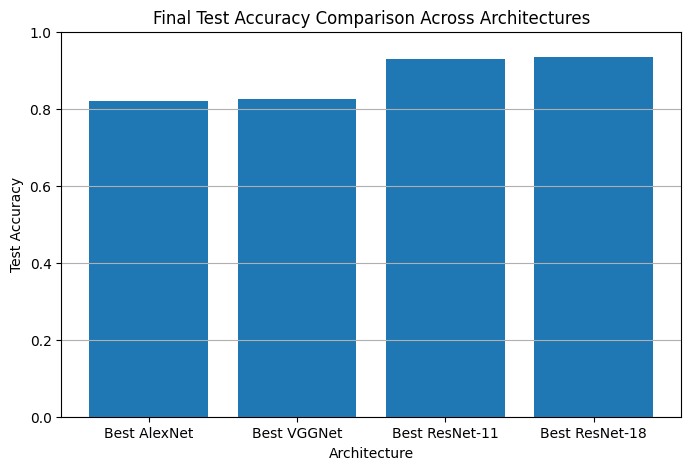

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    final_results_df["Architecture"],
    final_results_df["Test Accuracy"]
)

plt.xlabel("Architecture")
plt.ylabel("Test Accuracy")
plt.title("Final Test Accuracy Comparison Across Architectures")
plt.ylim(0, 1)
plt.grid(axis="y")
plt.show()

bonus

In [ ]:
def ResNet34_CIFAR10(dropout_p=0.0):
    return ResNetCIFAR(
        block=BasicBlock,
        num_blocks=[3, 4, 6, 3],
        num_classes=10,
        dropout_p=dropout_p
    )

In [ ]:
print("CIFARResNet" in globals())
print("ResNetCIFAR" in globals())
print("resnet11_baseline_model" in globals())
print("resnet18_baseline_model" in globals())
print("resnet18_dropout03_model" in globals())
print("resnet18_dropout05_model" in globals())

False
True
True
True
True
True
